# UASTHN Result Plot
Visualize predicted homography corners from Excel files on satellite maps.

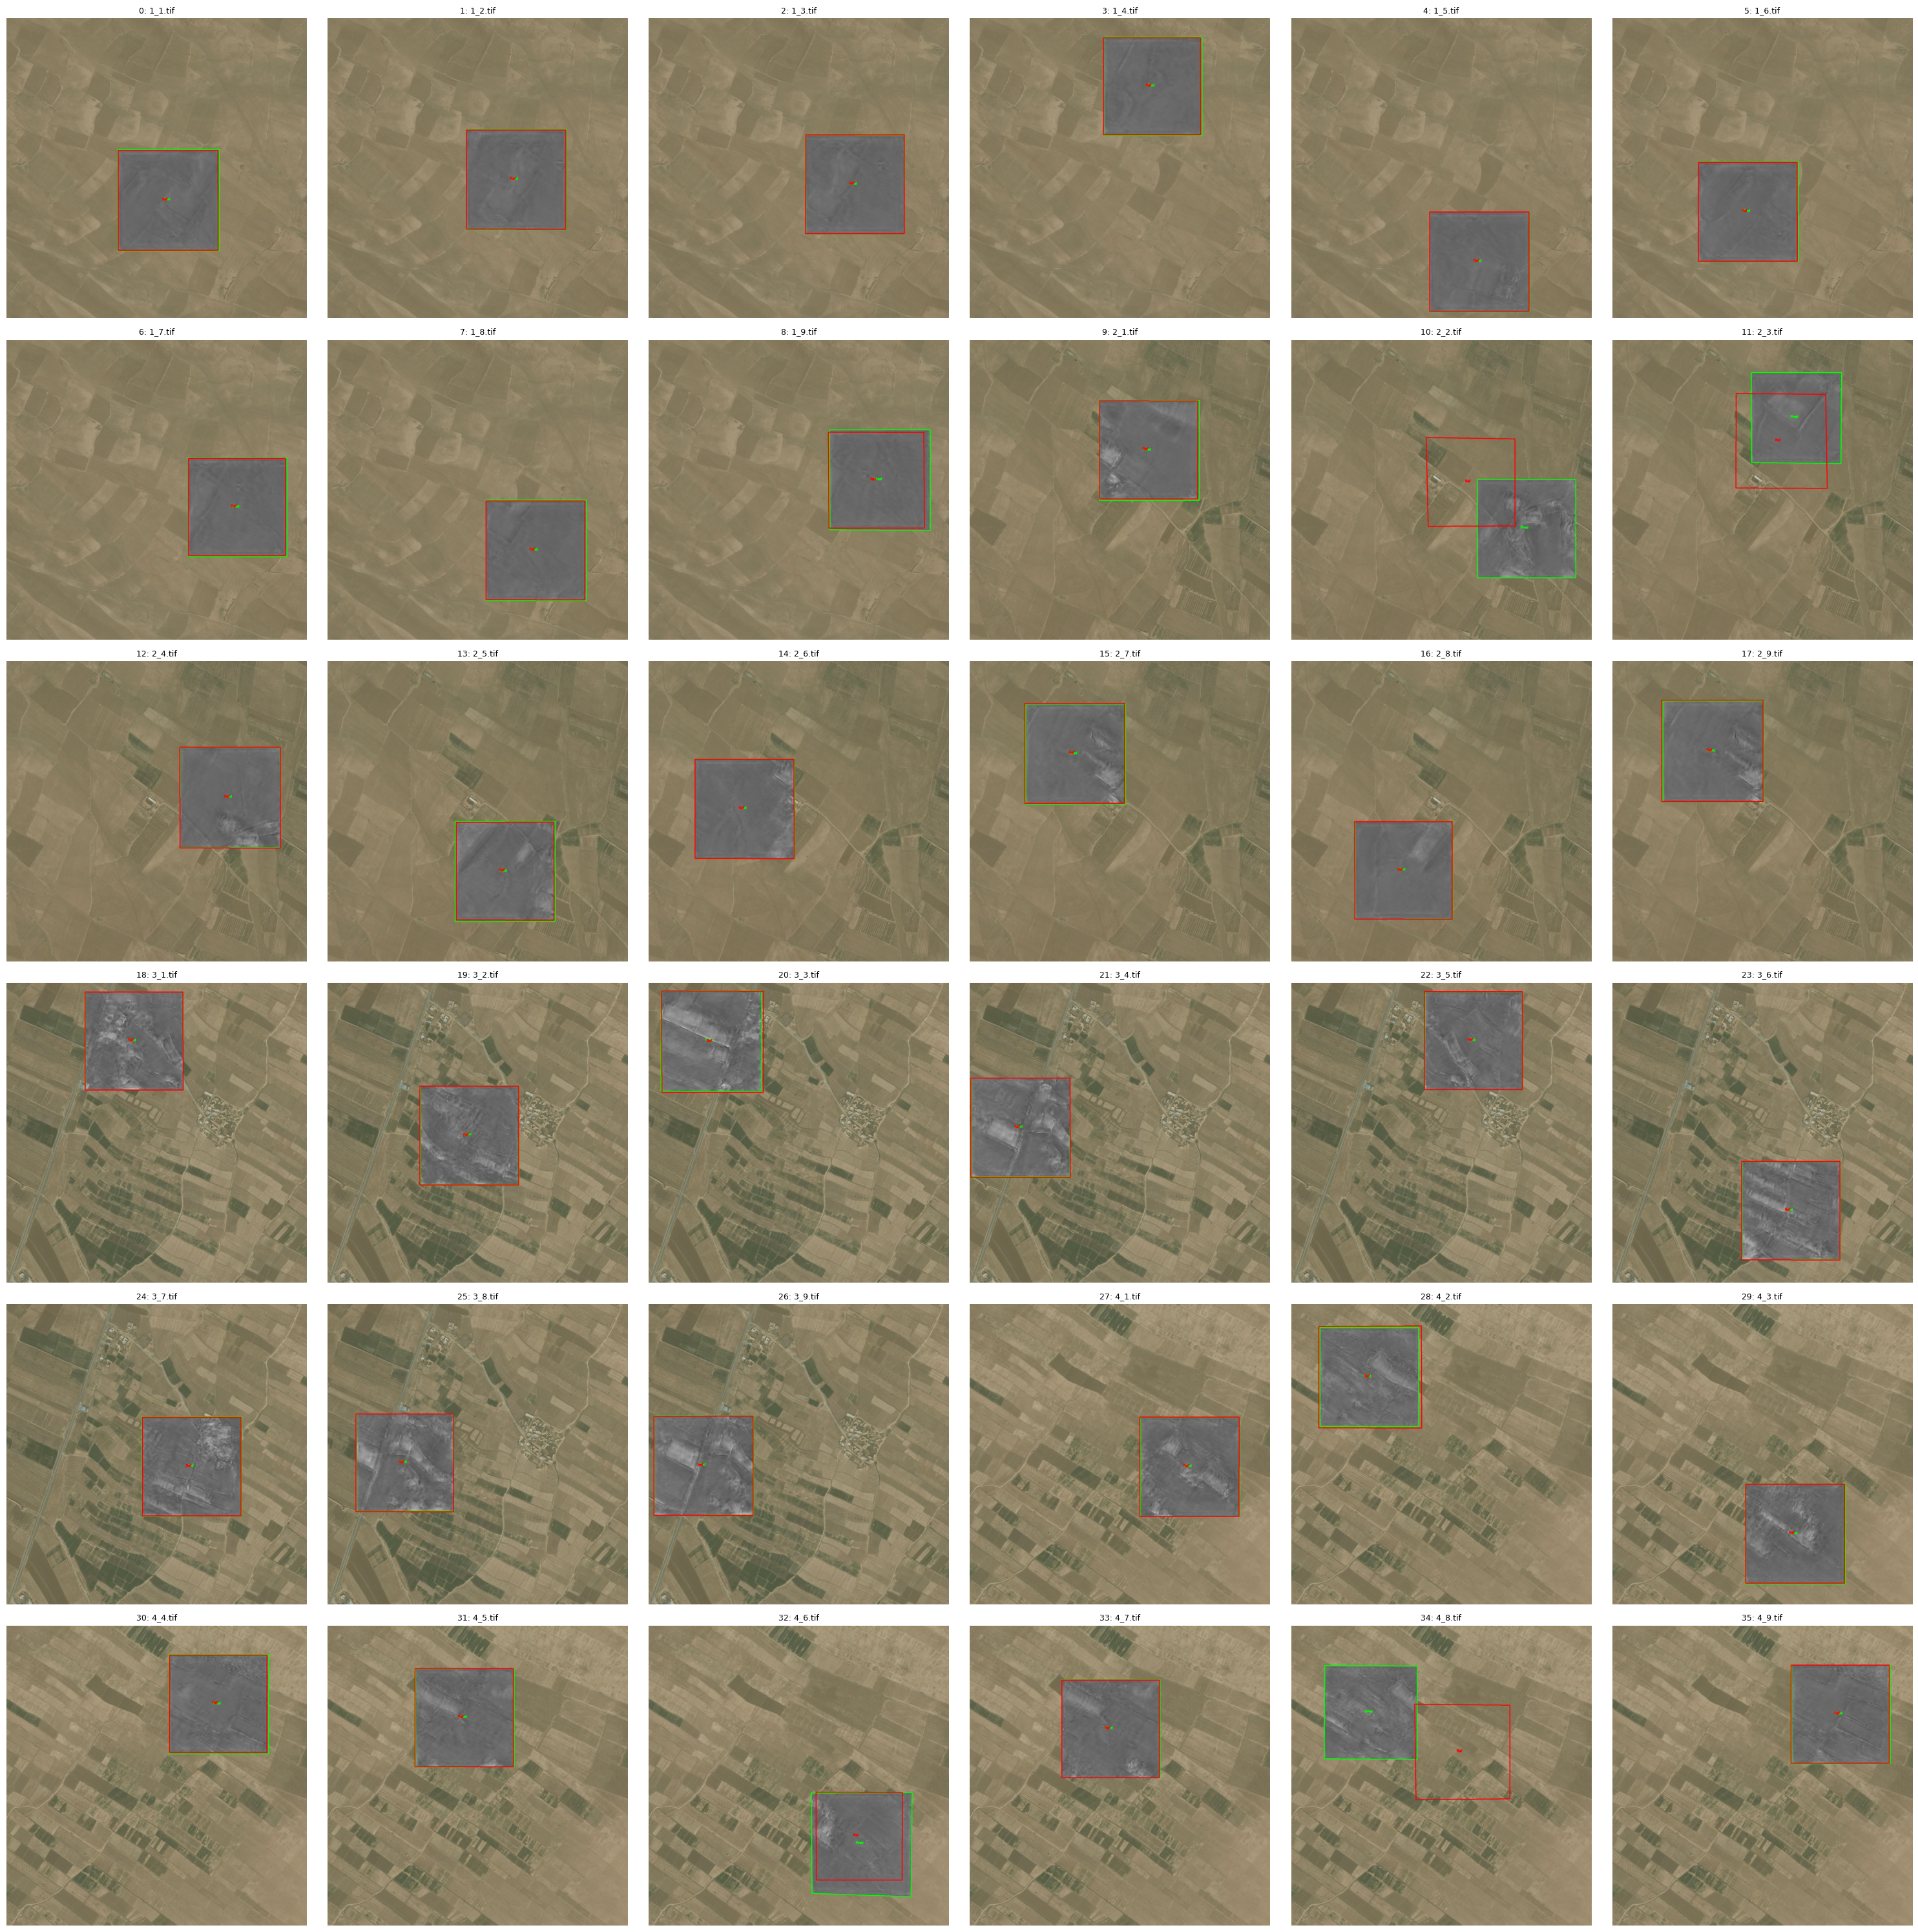

Rendered 36 overlays.


In [2]:
import os
import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ==============================
# CONFIG
# ==============================
PROJECT_ROOT = os.getcwd()
PRED_EXCEL = "js_excels/results_croptta_only.xlsx"
REF_EXCEL = "js_excels/dehat.xlsx"  # optional
USE_REFERENCE = True

NUM_IMAGES = 108      # None => all rows
GRID_COLS = 6
ALPHA_BLEND = 1    # 1.0 => keep only warped thermal pixels

SAVE_FIGURE = False
SAVE_PATH = "js_excels/overlay_grid.png"
FIG_DPI = 180

def resolve_img_path(path_text):
    path_text = str(path_text)
    if os.path.exists(path_text):
        return path_text
    candidate = os.path.join(PROJECT_ROOT, path_text)
    if os.path.exists(candidate):
        return candidate
    return None


def draw_quad(image, row, color, thickness, label=None):
    quad = np.array(
        [
            [row["x1"], row["y1"]],  # TL
            [row["x2"], row["y2"]],  # TR
            [row["x4"], row["y4"]],  # BR
            [row["x3"], row["y3"]],  # BL
        ],
        dtype=np.int32,
    )
    cv2.polylines(image, [quad], isClosed=True, color=color, thickness=thickness)
    if label is not None:
        center = np.mean(quad, axis=0).astype(np.int32)
        cv2.putText(
            image,
            label,
            (int(center[0]) - 30, int(center[1])),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color,
            2,
            cv2.LINE_AA,
        )


pred_excel_path = PRED_EXCEL if os.path.exists(PRED_EXCEL) else os.path.join(PROJECT_ROOT, PRED_EXCEL)
if not os.path.exists(pred_excel_path):
    raise FileNotFoundError(f"Prediction Excel not found: {pred_excel_path}")

pred_df = pd.read_excel(pred_excel_path)
ref_df = None

ref_excel_path = REF_EXCEL if os.path.exists(REF_EXCEL) else os.path.join(PROJECT_ROOT, REF_EXCEL)
if USE_REFERENCE and os.path.exists(ref_excel_path):
    ref_df = pd.read_excel(ref_excel_path)

if NUM_IMAGES is not None:
    pred_df = pred_df.head(NUM_IMAGES)
    if ref_df is not None:
        ref_df = ref_df.head(NUM_IMAGES)

required_cols = ["x1", "y1", "x2", "y2", "x3", "y3", "x4", "y4", "sat", "th"]
missing = [c for c in required_cols if c not in pred_df.columns]
if missing:
    raise KeyError(f"Missing columns in prediction Excel: {missing}")

results = []

for idx, row in pred_df.iterrows():
    sat_path = resolve_img_path(row["sat"])
    th_path = resolve_img_path(row["th"])

    if sat_path is None or th_path is None:
        print(f"[SKIP] Missing image at row {idx}")
        continue

    big_map = np.array(Image.open(sat_path).convert("RGB"))
    small_map = np.array(Image.open(th_path).convert("RGB"))

    h, w = small_map.shape[:2]
    src_pts = np.array(
        [
            [0, 0],
            [w - 1, 0],
            [0, h - 1],
            [w - 1, h - 1],
        ],
        dtype=np.float32,
    )

    dst_pts = np.array(
        [
            [row["x1"], row["y1"]],
            [row["x2"], row["y2"]],
            [row["x3"], row["y3"]],
            [row["x4"], row["y4"]],
        ],
        dtype=np.float32,
    )

    H, _ = cv2.findHomography(src_pts, dst_pts)
    if H is None:
        print(f"[FAIL] Homography failed at row {idx}")
        continue

    warped = cv2.warpPerspective(
        small_map,
        H,
        (big_map.shape[1], big_map.shape[0]),
    )

    overlay = big_map.copy()
    mask = np.any(warped != 0, axis=2)
    if ALPHA_BLEND >= 1.0:
        overlay[mask] = warped[mask]
    else:
        overlay[mask] = (
            ALPHA_BLEND * warped[mask] + (1.0 - ALPHA_BLEND) * overlay[mask]
        ).astype(np.uint8)

    draw_quad(overlay, row, color=(0, 255, 0), thickness=4, label="Pred")

    if ref_df is not None and idx < len(ref_df):
        row_ref = ref_df.iloc[idx]
        draw_quad(overlay, row_ref, color=(255, 0, 0), thickness=3, label="Ref")

    results.append((overlay, f"{idx}: {os.path.basename(th_path)}"))

if len(results) == 0:
    raise RuntimeError("No overlays were rendered. Check Excel paths and image paths.")

rows = math.ceil(len(results) / GRID_COLS)
plt.figure(figsize=(5 * GRID_COLS, 5 * rows))

for i, (img, title) in enumerate(results):
    plt.subplot(rows, GRID_COLS, i + 1)
    plt.imshow(img)
    plt.title(title, fontsize=9)
    plt.axis("off")

plt.tight_layout()

if SAVE_FIGURE:
    out_path = SAVE_PATH if os.path.isabs(SAVE_PATH) else os.path.join(PROJECT_ROOT, SAVE_PATH)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    print(f"Saved figure to: {out_path}")

plt.show()
print(f"Rendered {len(results)} overlays.")